In [1]:
import warnings
warnings.filterwarnings('ignore')
import random
import itertools
import json
import multiprocessing as mp
import numpy as np
import pandas as pd
import scipy
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
species_list = ["human", "fly"]
columns = ["0h-1", "0h-2", "3h-1", "3h-2", "6h-1", "6h-2"]
samples = ["20221128_K562_Actd_%dh_rep%d" % (t, r) for t, r in itertools.product([0, 3, 6], [1, 2])]

# Merge gene counts

Outputs:

    results/merged_gene_counts.{species}.csv

In [4]:
for species in species_list:
    array = []
    for s in samples:
        path = "../results/1_rnaseq/4_bams/%s.%s.rmdup.fpkm.tsv" % (s, species)
        print(path)
        d = pd.read_csv(path, sep="\t", index_col=0)
        d = d[(d["GeneType"] == "protein_coding") & (d["Canonical"])]
        d = d[~d["GeneName"].duplicated()]
        ss = d["Count"]
        ss.name = s
        ss.index = d["GeneName"]
        array.append(ss)
    m = pd.concat(array, axis=1)
    m.columns = columns
    m.to_csv("results/merged_gene_counts.%s.csv" % species)

../results/1_rnaseq/4_bams/20221128_K562_Actd_0h_rep1.human.rmdup.fpkm.tsv
../results/1_rnaseq/4_bams/20221128_K562_Actd_0h_rep2.human.rmdup.fpkm.tsv
../results/1_rnaseq/4_bams/20221128_K562_Actd_3h_rep1.human.rmdup.fpkm.tsv
../results/1_rnaseq/4_bams/20221128_K562_Actd_3h_rep2.human.rmdup.fpkm.tsv
../results/1_rnaseq/4_bams/20221128_K562_Actd_6h_rep1.human.rmdup.fpkm.tsv
../results/1_rnaseq/4_bams/20221128_K562_Actd_6h_rep2.human.rmdup.fpkm.tsv
../results/1_rnaseq/4_bams/20221128_K562_Actd_0h_rep1.fly.rmdup.fpkm.tsv
../results/1_rnaseq/4_bams/20221128_K562_Actd_0h_rep2.fly.rmdup.fpkm.tsv
../results/1_rnaseq/4_bams/20221128_K562_Actd_3h_rep1.fly.rmdup.fpkm.tsv
../results/1_rnaseq/4_bams/20221128_K562_Actd_3h_rep2.fly.rmdup.fpkm.tsv
../results/1_rnaseq/4_bams/20221128_K562_Actd_6h_rep1.fly.rmdup.fpkm.tsv
../results/1_rnaseq/4_bams/20221128_K562_Actd_6h_rep2.fly.rmdup.fpkm.tsv


# Correlation of gene counts

Outputs:

    figures/correlation_of_gene_counts.{species}.pdf

human
(19956, 6)
(9288, 6)
fly
(13968, 6)
(5170, 6)


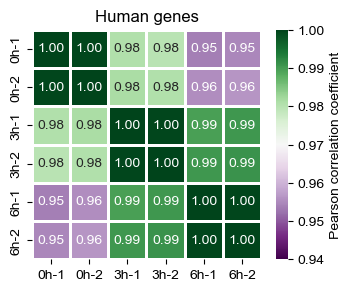

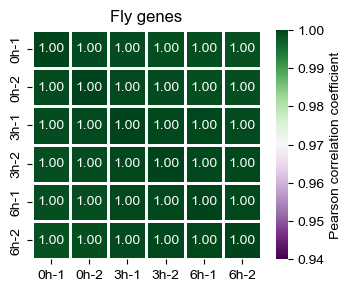

In [5]:
for species in species_list:
    print(species)
    m = pd.read_csv("results/merged_gene_counts.%s.csv" % species, index_col=0)
    print(m.shape)
    tmp = m[m.mean(axis=1) >= 100]
    print(tmp.shape)
    corr = tmp.corr()
    vmin = 0.94
    plt.figure(figsize=(3.7, 3))
    if species == "human":
        plt.title("Human genes")
    else:
        plt.title("Fly genes")
    sns.heatmap(corr, cmap="PRGn", vmin=vmin, vmax=1, 
                annot=True, fmt=".2f", lw=1, square=True, 
                cbar_kws=dict(label="Pearson correlation coefficient"))
    plt.tight_layout()
    plt.savefig("figures/correlation_of_gene_counts.%s.pdf" % species, dpi=300)

# Estimation of conversion factor

Outputs:

    figures/scatter_of_conversion_factor.pdf
    results/conversion_factors.json

In [6]:
def estimate_k(xs, ys):
    xs = np.log(xs)
    ys = np.log(ys)
    b = (sum(ys) - sum(xs)) / len(xs)
    k = np.e ** b
    return k

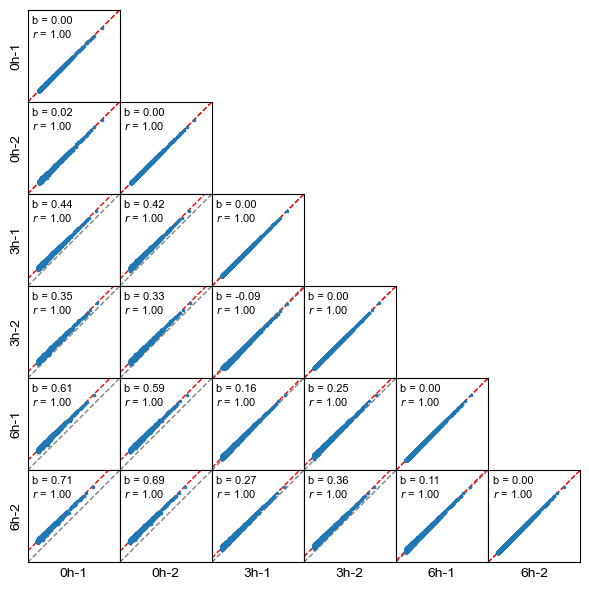

In [7]:
m = pd.read_csv("results/merged_gene_counts.fly.csv", index_col=0)
factors = dict()
fig, axs = plt.subplots(len(columns), len(columns), figsize=(6, 6))
for i in range(len(columns)):
    for j in range(len(columns)):
        c1, c2 = columns[j], columns[i]
        xs, ys = m[c1], m[c2]
        flags = (xs > 500) & (ys > 500)
        xs, ys = xs[flags], ys[flags]
        k = estimate_k(xs, ys)
        b = np.log(k)
        xs, ys = np.log(xs), np.log(ys)
        r = scipy.stats.pearsonr(xs, ys)[0]
        
        a1, b1 = np.polyfit(xs, ys, 1)
        vmin = min(min(xs), min(ys)) * 0.9
        vmax = max(max(xs), max(ys)) * 1.1
        factors["%s,%s" % (c1, c2)] = k
        if j > i:
            axs[i][j].set_visible(False)
            continue
        plt.sca(axs[i][j])
        plt.scatter(xs, ys, marker=".", alpha=1, color="C0", s=10, zorder=10)
        plt.xlim(vmin, vmax)
        plt.ylim(vmin, vmax)
        plt.plot([vmin, vmax], [vmin, vmax], ls="--", lw=1, color="grey")
        plt.plot([vmin, vmax], [vmin + b, vmax + b], ls="--", lw=1, color="red")
        w = vmax - vmin
        plt.text(vmin + w * 0.05, vmin + w * 0.85, "b = %.2f" % b, size=8)
        plt.text(vmin + w * 0.05, vmin + w * 0.70, "$r$ = %.2f" % r, size=8)
        if i == len(columns) - 1:
            plt.xlabel(c1)
        else:
            plt.xticks([])
        if j == 0:
            plt.ylabel(c2)
        else:
            plt.yticks([])
        plt.xticks([])
        plt.yticks([])
plt.tight_layout(w_pad=0, h_pad=0)
plt.savefig("figures/scatter_of_conversion_factor.pdf", dpi=300)

In [8]:
with open("results/conversion_factors.json", "w+") as fw:
    json.dump(factors, fw, indent=4)

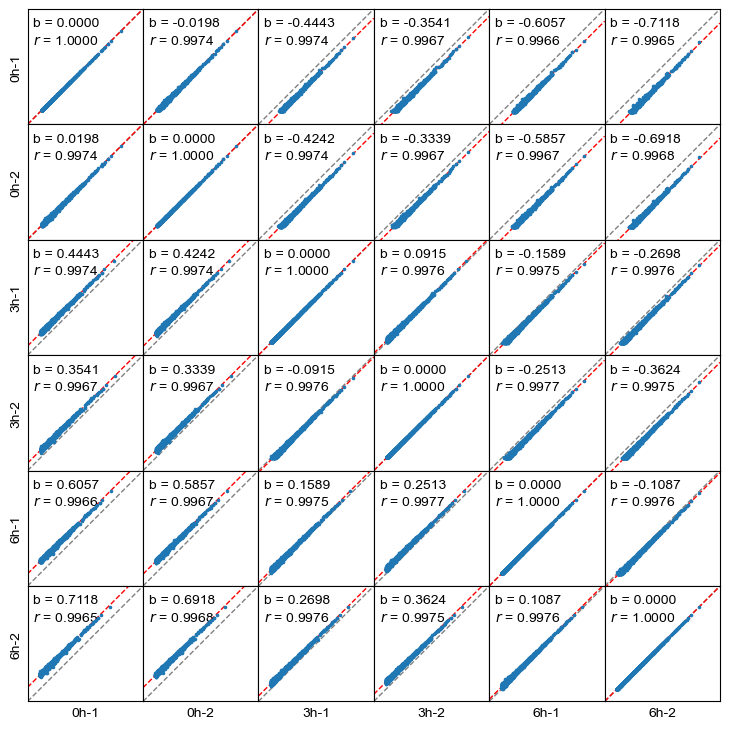

In [9]:
# For thesis
m = pd.read_csv("results/merged_gene_counts.fly.csv", index_col=0)
fig, axs = plt.subplots(len(columns), len(columns), figsize=(7.4, 7.4))
for i in range(len(columns)):
    for j in range(len(columns)):
        c1, c2 = columns[j], columns[i]
        xs, ys = m[c1], m[c2]
        flags = (xs >= 500) & (ys >= 500)
        xs, ys = xs[flags], ys[flags]
        k = estimate_k(xs, ys)
        b = np.log(k)
        xs, ys = np.log(xs), np.log(ys)
        r = scipy.stats.pearsonr(xs, ys)[0]
        a1, b1 = np.polyfit(xs, ys, 1)
        vmin = min(min(xs), min(ys)) * 0.9
        vmax = max(max(xs), max(ys)) * 1.1
        plt.sca(axs[i][j])
        plt.scatter(xs, ys, marker=".", alpha=1, color="C0", s=10, zorder=10)
        plt.xlim(vmin, vmax)
        plt.ylim(vmin, vmax)
        plt.plot([vmin, vmax], [vmin, vmax], ls="--", lw=1, color="grey")
        plt.plot([vmin, vmax], [vmin + b, vmax + b], ls="--", lw=1, color="red")
        w = vmax - vmin
        plt.text(vmin + w * 0.05, vmin + w * 0.85, "b = %.4f" % b)
        plt.text(vmin + w * 0.05, vmin + w * 0.70, "$r$ = %.4f" % r)
        if i == len(columns) - 1:
            plt.xlabel(c1)
        else:
            plt.xticks([])
        if j == 0:
            plt.ylabel(c2)
        else:
            plt.yticks([])
        plt.xticks([])
        plt.yticks([])
plt.tight_layout(w_pad=0, h_pad=0)
plt.savefig("figures/thesis_scatter_of_conversion_factor.pdf", dpi=300)

# Estimation of half-life

Outputs:

    results/halflife_of_k562_genes.tsv
    

In [10]:
def decay_rate_curve(t, k):
    return np.exp(-k*t)
    
def fit_decay_rate(ys0):
    k, r2 = np.nan, np.nan
    try:
        xs = np.array([0, 0, 3, 3, 6, 6])
        popt, pcov = curve_fit(decay_rate_curve, xs, ys, bounds=(0, 10))
        k = popt[0]
        r2 = r2_score(ys, np.array([decay_rate_curve(x, k) for x in xs]))
    except Exception:
        pass
    return k, r2

## Half-life of genes

In [11]:
# Merge counts
array = []
for sample, c in zip(samples, columns):
    path = "../results/1_rnaseq/4_bams/%s.human.rmdup.fpkm.tsv" % sample
    df = pd.read_csv(path, sep="\t", index_col=0)
    s = df["FPKM"]
    s.name = "FPKM.%s" % c
    array.append(s)
    s = df["Count"]
    s.name = "Count.%s" % c
    array.append(s)
m = pd.concat(array, axis=1)
m = m[list(sorted(m.columns))]
print(m.shape)

(244939, 12)


In [12]:
# Normalized
factors = json.load(open("results/conversion_factors.json"))
for c in columns:
    factor = factors["%s,%s" % (c, "0h-1")]
    m["Count.%s.norm" % c] = m["Count.%s" % c] * factor

In [13]:
# Relative abundance
mean_0 = m[["Count.0h-1.norm", "Count.0h-2.norm"]].mean(axis=1)
for c in columns:
    m["Abundance.%s" % c] = m["Count.%s.norm" % c] / mean_0

In [14]:
# decay rate curve fitting
Ks = []
Rs = []
for i, ys in enumerate(m[["Abundance.%s" % c for c in columns]].values):
    if i % 10000 == 0:
        print("%d/%d" % (i, m.shape[0]))
    k, r2 = fit_decay_rate(ys)
    Ks.append(k)
    Rs.append(r2)
m["DecayRate"] = Ks
m["DecayRate.R2Score"] = Rs
m["Halflife"] = np.log(2) / m["DecayRate"]

0/244939
10000/244939
20000/244939
30000/244939
40000/244939
50000/244939
60000/244939
70000/244939
80000/244939
90000/244939
100000/244939
110000/244939
120000/244939
130000/244939
140000/244939
150000/244939
160000/244939
170000/244939
180000/244939
190000/244939
200000/244939
210000/244939
220000/244939
230000/244939
240000/244939


In [15]:
anno = pd.read_csv("../../share/homo_sapiens/GRCh38.p13/gencode.v39.transcript_info.added_canonical.csv", index_col=0)
anno.drop(columns=["Length"])
m2 = m.merge(anno, left_index=True, right_index=True)
m2.to_csv("results/halflife_of_k562_genes.tsv", sep="\t")

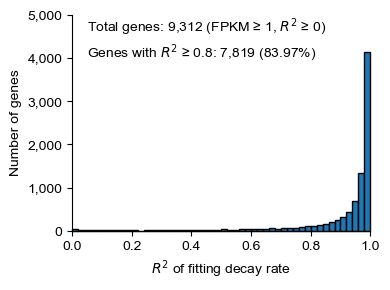

In [16]:
m = pd.read_csv("results/halflife_of_k562_genes.tsv", sep="\t", index_col=0)
m = m[(m["GeneType"] == "protein_coding") & (m["Canonical"])]
m = m[~m["GeneID"].duplicated()]
m = m[(m["FPKM.0h-1"] >= 1) & (m["FPKM.0h-2"] >= 1) & (m["DecayRate.R2Score"] >= 0)]

plt.figure(figsize=(4, 3))
ret = plt.hist(m["DecayRate.R2Score"], range=(0, 1), bins=50, edgecolor="black", color="C0", clip_on=False)
plt.xlim(0, 1)
ylim = 5000
plt.ylim(0, ylim)
plt.text(0.05, ylim * 0.92, r"Total genes: %s (FPKM ≥ 1, $\it{R}^2$ ≥ 0)" % format(len(m), ","))
n = len(m[m["DecayRate.R2Score"] >= 0.8])
plt.text(0.05, ylim * 0.8, "Genes with $\it{R}^2$ ≥ 0.8: %s (%.2f%%)" % (format(n, ","), n * 100 / len(m)))
ys1 = np.arange(0, 5000 + 1, 1000)
plt.yticks(ys1, [format(y, ",") for y in ys1])
plt.xlabel("$\it{R}^2$ of fitting decay rate")
plt.ylabel("Number of genes")
for loc in ["right", "top"]:
    plt.gca().spines[loc].set_visible(False)
plt.tight_layout()
plt.savefig("figures/barplot_r2_score.pdf")

## Half-life of introns

In [ ]:
columns = ["0h-1", "0h-2", "3h-1", "3h-2", "6h-1", "6h-2"]
paths = [
    "../results/1_rnaseq/4_bams/20221128_K562_Actd_0h_rep1.human.rmdup.intron_count.tsv",
    "../results/1_rnaseq/4_bams/20221128_K562_Actd_0h_rep2.human.rmdup.intron_count.tsv",
    "../results/1_rnaseq/4_bams/20221128_K562_Actd_3h_rep1.human.rmdup.intron_count.tsv",
    "../results/1_rnaseq/4_bams/20221128_K562_Actd_3h_rep2.human.rmdup.intron_count.tsv",
    "../results/1_rnaseq/4_bams/20221128_K562_Actd_6h_rep1.human.rmdup.intron_count.tsv",
    "../results/1_rnaseq/4_bams/20221128_K562_Actd_6h_rep2.human.rmdup.intron_count.tsv"]

# counts
array = []
motifs = dict()
knowns = dict()
for c, path in zip(columns, paths):
    d = pd.read_csv(path, sep="\t")
    ks = []
    for chrom, start, end, strand, motif, known in d[["Chrom", "Start", "End", "Strand", "Motif", "Known"]].values:
        k = (chrom, start, end, strand)
        ks.append(k)
        motifs[k] = motif
        knowns[k] = known
    s = d["Count"]
    s.index = ks
    s.name = "Count.%s" % c
    array.append(s)        
dat = pd.concat(array, axis=1).fillna(0).astype(int)

# normalized
factors = json.load(open("results/conversion_factors.json"))
for c in columns:
    x = factors["%s,%s" % (c, "0h-1")]
    dat["Count.%s.norm" % c] = dat["Count.%s" % c] * x

# abundance
for c in columns:
    dat["Abundance.%s" % c] = dat["Count.%s.norm" % c] / dat[["Count.0h-1.norm", "Count.0h-2.norm"]].mean(axis=1)

dat["Chrom"] = [idx[0] for idx in dat.index]
dat["Start"] = [idx[1] for idx in dat.index]
dat["End"] = [idx[2] for idx in dat.index]
dat["Strand"] = [idx[3] for idx in dat.index]
dat["Motif"] = dat.index.map(motifs)
dat["Known"] = dat.index.map(knowns)

if True:
    Ts = []
    Rs = []
    for ys0 in dat[["Abundance.%s" % c for c in columns]].values:
        # T, R = halflife_from_curve_fitting(ys0)
        D, R = fit_decay_rate(ys0)
        T = np.log(2)/D
        Ts.append(T)
        Rs.append(R)
    dat["T"] = Ts
    dat["R2.Score"] = Rs

dat.to_csv("results/halflife_of_introns.tsv", sep="\t", index=False)

# Plot decay curve of star genes

MYC, PDLIM5, ACTB, GAPDH

MYC
Abundance.0h-1    0.990186
Abundance.0h-2    1.009814
Abundance.3h-1    0.020976
Abundance.3h-2    0.021566
Abundance.6h-1    0.013179
Abundance.6h-2    0.012228
Name: ENST00000621592.8, dtype: object
PDLIM5
Abundance.0h-1    1.008521
Abundance.0h-2    0.991479
Abundance.3h-1    0.624894
Abundance.3h-2    0.640365
Abundance.6h-1    0.472928
Abundance.6h-2    0.501038
Name: ENST00000317968.9, dtype: object
ACTB
Abundance.0h-1    0.988236
Abundance.0h-2    1.011764
Abundance.3h-1    0.800104
Abundance.3h-2     0.83547
Abundance.6h-1     0.65354
Abundance.6h-2    0.651785
Name: ENST00000646664.1, dtype: object
GAPDH
Abundance.0h-1     0.98834
Abundance.0h-2     1.01166
Abundance.3h-1    0.928786
Abundance.3h-2    0.979033
Abundance.6h-1     0.86657
Abundance.6h-2    0.836817
Name: ENST00000229239.10, dtype: object


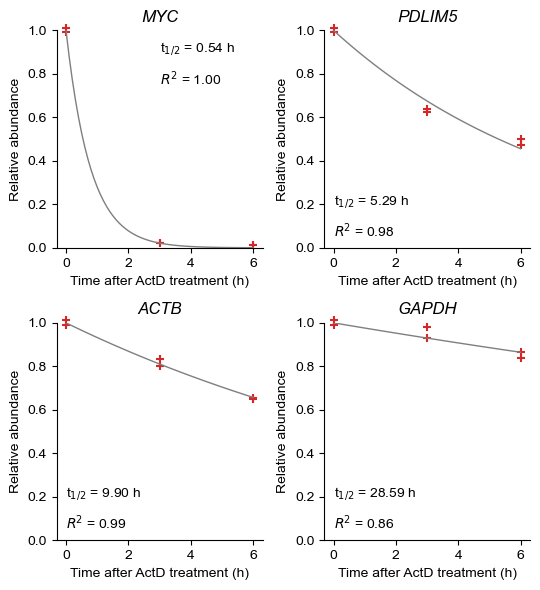

In [20]:
df = pd.read_csv("results/halflife_of_k562_genes.tsv", sep="\t", index_col=0)
df["T"] = df["Halflife"]
columns = ["0h-1", "0h-2", "3h-1", "3h-2", "6h-1", "6h-2"]
tids = [
    "ENST00000621592.8", # MYC
    "ENST00000317968.9", # PDLIM5
    "ENST00000646664.1", # ACTB
    "ENST00000229239.10", # GAPDH
]

fig, axs = plt.subplots(2, 2, figsize=(5.5, 6), sharex=False, sharey=False)
for i, tid in enumerate(tids):
    m = int(i / 2)
    n = i % 2
    plt.sca(axs[m][n])
    
    T = df.loc[tid]["T"]
    D = df.loc[tid]["DecayRate.R2Score"]
    gname = df.loc[tid]["GeneName"]
    xs = np.array([0, 0, 3, 3, 6, 6])
    ys = df.loc[tid][["Abundance.%s" % c for c in columns]]
    print(gname)
    print(ys)
    xs1 = np.arange(0, 6.1, 0.1)
    ys1 = np.array([0.5**(x/T)for x in xs1])
    
    plt.title(gname, style="italic")
    plt.scatter(xs, ys, color="C3", marker="+", clip_on=False)
    plt.plot(xs1, ys1, lw=1, color="C7")
    if gname == "MYC":
        plt.text(3, 0.9, "t$_{1/2}$ = %.2f h" % T)
        plt.text(3, 0.75, "$R^2$ = %.2f" % D)
    else:
        plt.text(0, 0.2, "t$_{1/2}$ = %.2f h" % T)
        plt.text(0, 0.05, "${R}$$^{\mathit{2}}$ = %.2f" % D)
    #if m == 1:
    plt.xlabel("Time after ActD treatment (h)")
    #if n == 0:
    plt.ylabel("Relative abundance")
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("figures/decay_curve.example_genes.pdf")

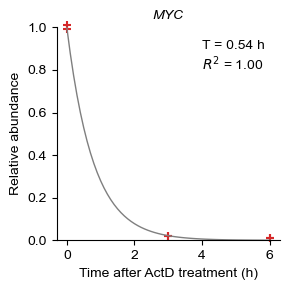

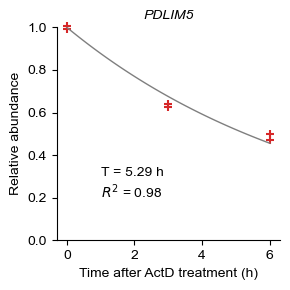

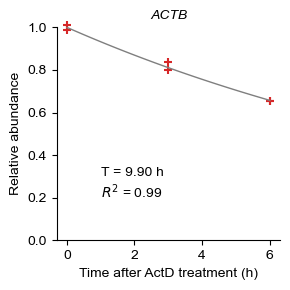

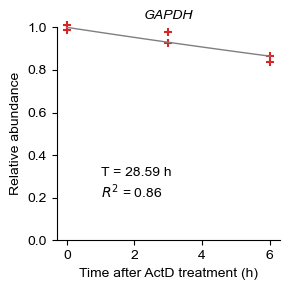

In [32]:
# For thesis
m = pd.read_csv("reports/halflife_of_k562_genes.tsv", sep="\t", index_col=0)
tids = [
    "ENST00000621592.8", # MYC
    "ENST00000317968.9", # PDLIM5
    "ENST00000646664.1", # ACTB
    "ENST00000229239.10", # GAPDH
]

for i, tid in enumerate(tids):
    half_life = m.loc[tid]["Halflife"]
    decay_rate = m.loc[tid]["DecayRate"]
    r2 = m.loc[tid]["DecayRate.R2Score"]
    gname = m.loc[tid]["GeneName"]

    xs = np.array([0, 0, 3, 3, 6, 6])
    ys = m.loc[tid][["Abundance.%s" % c for c in columns]].values

    # print("Gene:", gname)
    # print("Abundance:", ys)
    # print("Halflife:", round(half_life, 2))
    # print("Decay rate:", round(decay_rate, 2))
    # print("R2 score:", round(r2, 2))
    
    xs1 = np.arange(0, 6.1, 0.1)
    ys1 = np.array([np.e ** (-decay_rate * x) for x in xs1])

    plt.figure(figsize=(3, 3))
    plt.title(gname, style="italic", size=10)
    plt.scatter(xs, ys, color="C3", marker="+", clip_on=False)
    plt.plot(xs1, ys1, lw=1, color="C7")
    plt.xlabel("Time after ActD treatment (h)")
    plt.ylabel("Relative abundance")
    if gname == "MYC":
        plt.text(4, 0.9, "T = %.2f h" % round(half_life, 2))
        plt.text(4, 0.8, "$\it{R}^2$ = %.2f" % round(r2, 2))
    else:
        plt.text(1, 0.3, "T = %.2f h" % round(half_life, 2))
        plt.text(1, 0.2, "$\it{R}^2$ = %.2f" % round(r2, 2)) 
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.savefig("figures/thesis_decay_curve.%s.pdf" % gname)

# Allele-specific decay diversity

TODO!

In [45]:
data_factors = json.load(open("results/transform_factor.json"))
dates = ["20221128", "20221205"]
columns = ["0h-1", "0h-2", "3h-1", "3h-2", "6h-1", "6h-2"]

date = dates[0]
samples = []
for t in [0, 3, 6]:
    for r in [1, 2]:
        s = "%s_K562_Actd_%dh_rep%d" % (date, t, r)
        samples.append(s)
array = []
for sample, column in zip(samples, columns):
    d = pd.read_csv("results/snps/counts/%s.tsv" % sample, sep="\t")
    d.index = ["%s:%d" % (chrom, start) for chrom, start in d[["Chrom", "Start"]].values]
    d = d[d.columns[3:]]
    d.columns = ["%s_%s" % (column, c) for c in d.columns]
    array.append(d)
df = pd.concat(array, axis=1, join="outer").fillna(0)

In [80]:
for hp in ["HP1", "HP2"]:
    for column in columns:
        factor = data_factors[date]["%s,0h-1" % column]
        # df["%s_%s" % (column, hp)] * factor
        df["%s_%s_adj" % (column, hp)] = df["%s_%s" % (column, hp)] * factor
        
    mean_0 =  df[["0h-1_%s_adj" % hp, "0h-2_%s_adj" % hp]].mean(axis=1)
    for column in columns:
        df["%s_%s_adj_p" % (column, hp)] = df["%s_%s_adj" % (column, hp)] / mean_0
        
    Ts = []
    Ds = []
    for vs in df[[c + "_%s_adj_p" % hp for c in columns]].values:
        xs0 = [0, 0, 3, 3, 6, 6]
        ys0 = vs
        ys = ys0[2:]
        xs = np.array([3, 3, 6, 6])
        Y = np.log2(-np.log2(ys))
        X = np.log2(xs)
        b = sum(Y - X) / len(Y)
        T = 1 / (2 ** b)
        D = sum([abs(y - 2 ** (-x/T)) for x, y in zip(xs0, ys0)])
        Ts.append(T)
        Ds.append(D)
    df["T_%s" % hp] = Ts
    df["D_%s" % hp] = Ds
    df["P_Nascent_%s" % hp] = 1 - 0.5 ** (3 / df["T_%s" % hp])
    df["K_%s" % hp] = mean_0 / df["T_%s" % hp] * np.log(2)

/home/chenzonggui/miniconda3/lib/python3.6/site-packages/ipykernel_launcher.py:18: RuntimeWarning: invalid value encountered in log2
/home/chenzonggui/miniconda3/lib/python3.6/site-packages/ipykernel_launcher.py:18: RuntimeWarning: divide by zero encountered in log2
/home/chenzonggui/miniconda3/lib/python3.6/site-packages/ipykernel_launcher.py:22: RuntimeWarning: invalid value encountered in double_scalars
/home/chenzonggui/miniconda3/lib/python3.6/site-packages/ipykernel_launcher.py:22: RuntimeWarning: divide by zero encountered in double_scalars


In [81]:
df1 = df[(df["0h-1_Assigned%"] > 0.95) & (df["0h-2_Assigned%"] > 0.95)] # assigned
df1 = df1[(df1["0h-1_Log2FC"].abs() < 2) & (df1["0h-2_Log2FC"].abs() < 2)]
df1 = df1[(df1["D_HP1"] < 0.2) & (df1["D_HP2"] < 0.2)]
df1

,0h-1_UnAssinged,0h-1_HP1,0h-1_HP2,0h-1_Assigned,0h-1_Assigned%,0h-1_Log2FC,0h-2_UnAssinged,0h-2_HP1,0h-2_HP2,0h-2_Assigned,...,6h-1_HP2_adj_p,6h-2_HP2_adj_p,T_HP1,D_HP1,T_HP2,D_HP2,P_Nascent_HP1,P_Nascent_HP2,K_HP1,K_HP2
chr1:2308943,0,38,33,71,1.000000,0.203533,1,38,36,74,...,0.032133,0.043604,1.443515,0.053451,1.409918,0.166829,0.763200,0.771191,18.041512,16.761817
chr1:42926578,2,213,354,567,0.996485,-0.732896,1,210,338,548,...,0.118457,0.121645,2.002636,0.079319,2.016026,0.103092,0.645962,0.643512,72.385907,117.653544
chr1:42929963,0,212,277,489,1.000000,-0.385822,0,218,316,534,...,0.117804,0.130256,1.847667,0.105555,2.127734,0.192365,0.675491,0.623675,79.736362,95.431741
chr1:42930742,2,195,301,496,0.995984,-0.626289,1,210,321,531,...,0.167512,0.132196,2.042205,0.111158,2.157529,0.176763,0.638767,0.618562,67.928684,98.754181
chr1:65392461,0,100,39,139,1.000000,1.358454,0,92,42,134,...,0.095796,0.061902,1.449124,0.172438,1.567438,0.140376,0.761876,0.734635,45.423662,17.700770
chr1:150966094,4,428,233,661,0.993985,0.877281,4,446,233,679,...,0.661010,0.613049,8.150978,0.091018,10.496497,0.177152,0.225173,0.179719,36.735046,15.213257
chr1:203852185,0,106,53,159,1.000000,1.000000,0,113,54,167,...,0.176060,0.215490,2.780268,0.129937,2.360902,0.107709,0.526654,0.585542,26.982371,15.528887
chr1:230281203,3,56,138,194,0.984772,-1.301170,2,57,130,187,...,0.661282,0.646845,20.126840,0.168276,8.933353,0.170509,0.098159,0.207666,1.923711,10.283679
chr1:230281917,0,35,91,126,1.000000,-1.378512,0,36,96,132,...,0.628269,0.697060,7.428705,0.139864,9.119671,0.158591,0.244156,0.203889,3.274585,7.024428
chr1:241872135,0,139,56,195,1.000000,1.311586,0,137,55,192,...,0.119774,0.117385,2.042249,0.124094,1.727890,0.183848,0.638760,0.699845,46.314500,22.015685


limit_output extension: Maximum message size of 10000 exceeded with 31699 characters

In [82]:
df1[["0h-1_HP1_adj", "0h-2_HP1_adj", "0h-1_HP2_adj", "0h-2_HP2_adj", "T_HP1", "T_HP2", "P_Nascent_HP1", "P_Nascent_HP2"]]

,0h-1_HP1_adj,0h-2_HP1_adj,0h-1_HP2_adj,0h-2_HP2_adj,T_HP1,T_HP2,P_Nascent_HP1,P_Nascent_HP2
chr1:2308943,38.0,37.144779,33.0,35.189791,1.443515,1.409918,0.763200,0.771191
chr1:42926578,213.0,205.273781,354.0,330.393038,2.002636,2.016026,0.645962,0.643512
chr1:42929963,212.0,213.093735,277.0,308.888166,1.847667,2.127734,0.675491,0.623675
chr1:42930742,195.0,205.273781,301.0,313.775637,2.042205,2.157529,0.638767,0.618562
chr1:65392461,100.0,89.929466,39.0,41.054756,1.449124,1.567438,0.761876,0.734635
chr1:150966094,428.0,435.962411,233.0,227.756148,8.150978,10.496497,0.225173,0.179719
chr1:203852185,106.0,110.456844,53.0,52.784687,2.780268,2.360902,0.526654,0.585542
chr1:230281203,56.0,55.717169,138.0,127.074245,20.126840,8.933353,0.098159,0.207666
chr1:230281917,35.0,35.189791,91.0,93.839443,7.428705,9.119671,0.244156,0.203889
chr1:241872135,139.0,133.916705,56.0,53.762181,2.042249,1.727890,0.638760,0.699845


limit_output extension: Maximum message size of 10000 exceeded with 15089 characters

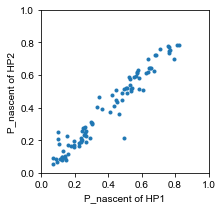

In [83]:
xs = df1["P_Nascent_HP1"]
ys = df1["P_Nascent_HP2"]
plt.figure(figsize=(3, 3))
plt.scatter(xs, ys, marker=".")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("P_nascent of HP1")
plt.ylabel("P_nascent of HP2")
plt.show()

In [85]:
df1[df1["P_Nascent_HP1"] / df1["P_Nascent_HP2"] > 2].iloc[0]

0h-1_UnAssinged      2.000000
0h-1_HP1           165.000000
0h-1_HP2            65.000000
0h-1_Assigned      230.000000
0h-1_Assigned%       0.991379
0h-1_Log2FC          1.343954
0h-2_UnAssinged      6.000000
0h-2_HP1           187.000000
0h-2_HP2            66.000000
0h-2_Assigned      253.000000
0h-2_Assigned%       0.976834
0h-2_Log2FC          1.502500
3h-1_UnAssinged      5.000000
3h-1_HP1           145.000000
3h-1_HP2            80.000000
3h-1_Assigned      225.000000
3h-1_Assigned%       0.978261
3h-1_Log2FC          0.857981
3h-2_UnAssinged      2.000000
3h-2_HP1           120.000000
3h-2_HP2            72.000000
3h-2_Assigned      192.000000
3h-2_Assigned%       0.989691
3h-2_Log2FC          0.736966
6h-1_UnAssinged      4.000000
6h-1_HP1            82.000000
6h-1_HP2            75.000000
6h-1_Assigned      157.000000
6h-1_Assigned%       0.975155
6h-1_Log2FC          0.128733
                      ...    
3h-1_HP1_adj        93.253383
3h-2_HP1_adj        84.084285
6h-1_HP1_a

In [2]:
m = pd.read_csv("results/snps/counts/20221128_K562_Actd_0h_rep1.tsv", sep="\t")
m

,Chrom,Start,End,UnAssinged,HP1,HP2,Assigned,Assigned%,Log2FC
0,chr1,14652,14653,1,47,16,63,0.984375,1.554589
1,chr1,15188,15189,2,11,5,16,0.888889,1.137504
2,chr1,15203,15204,2,11,6,17,0.894737,0.874469
3,chr1,15819,15820,3,11,8,19,0.863636,0.459432
4,chr1,16724,16725,4,33,14,47,0.921569,1.237039
...,...,...,...,...,...,...,...,...,...
16833,chrY,11155880,11155881,14,6,32,38,0.730769,-2.415037
16834,chrY,11163092,11163093,15,24,89,113,0.882812,-1.890771
16835,chrY,11209744,11209745,52,48,96,144,0.734694,-1.000000
16836,chrY,11214965,11214966,32,51,82,133,0.806061,-0.685127


(array([1200.,  486.,  390.,  385.,  394.,  511.,  708.,  992., 1937.,
        9835.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

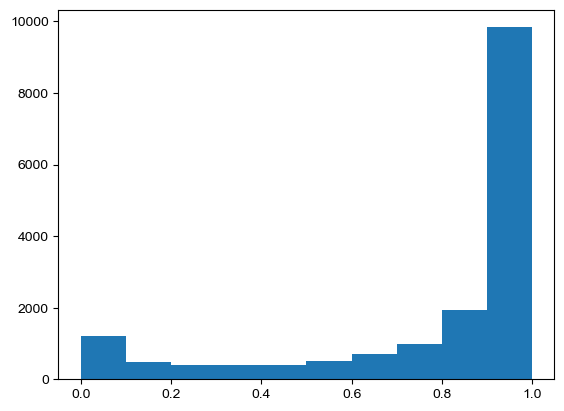

In [4]:
plt.hist(m["Assigned%"])